<a href="https://colab.research.google.com/github/w4ib4/AI-and-Machine-Learning/blob/main/2438446_SrijanTamang_Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 – Final Portfolio Assessment 2026
## Part II: Vision Tasks — Skin Cancer Image Classification with CNNs

**Dataset:** Skin Cancer Classification (ISIC Archive)  
**Classes:** 9 skin lesion categories  
**Framework:** TensorFlow / Keras  
**Environment:** Google Colab (GPU recommended)

---
### Table of Contents
1. Setup & Dependencies
2. Dataset Upload & Extraction
3. **Part A – CNN from Scratch**
   - 3.1 Data Understanding, Analysis & Visualisation
   - 3.2 Baseline CNN – Design, Train & Evaluate
   - 3.3 Deeper CNN with Regularisation
   - 3.4 Experimentation & Comparative Analysis
4. **Part B – Transfer Learning (MobileNetV2)**
   - 4.1 Load & Adapt Pre-Trained Model
   - 4.2 Feature Extraction Training
   - 4.3 Fine-Tuning
   - 4.4 Model Evaluation & Comparison
---

## 1. Setup & Dependencies

In [2]:
# Install / verify required libraries (Colab already has most of these)
!pip install -q tensorflow matplotlib numpy scikit-learn seaborn pillow

In [3]:
import os
import time
import zipfile
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')
print('All libraries imported successfully.')

TensorFlow version : 2.20.0
GPU available      : True
All libraries imported successfully.


## 2. Dataset Upload & Extraction

> **Instructions:**  
> Upload the zip file `Skin Cancer Classification-20260417T072726Z-3-001.zip` using the Colab file upload widget (Files panel → Upload), then run the cell below.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# ── Option A: Upload manually via Colab Files panel ──────────────────────────
# from google.colab import files
# uploaded = files.upload()   # uncomment and run if uploading interactively

# ── Option B: Mount Google Drive (if zip is already in Drive) ────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# ZIP_PATH = '/content/drive/MyDrive/Skin Cancer Classification-20260417T072726Z-3-001.zip'

# ── Set zip path (adjust if needed) ─────────────────────────────────────────
ZIP_PATH = '/content/drive/MyDrive/AI Datasets/Skin Cancer Classification-20260417T072726Z-3-001.zip'
EXTRACT_DIR = '/content/skin_cancer_data'

if not os.path.exists(EXTRACT_DIR):
    print(f'Extracting {ZIP_PATH} …')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print('Extraction complete.')
else:
    print('Dataset already extracted.')

# Locate Train / Test directories
BASE_DIR   = os.path.join(EXTRACT_DIR, 'Skin Cancer Classification')
TRAIN_DIR  = os.path.join(BASE_DIR, 'Train')
TEST_DIR   = os.path.join(BASE_DIR, 'Test')

print(f'Train dir : {TRAIN_DIR}')
print(f'Test  dir : {TEST_DIR}')
print('Classes found:', sorted(os.listdir(TRAIN_DIR)))

Dataset already extracted.
Train dir : /content/skin_cancer_data/Skin Cancer Classification/Train
Test  dir : /content/skin_cancer_data/Skin Cancer Classification/Test
Classes found: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


---
## 3. Part A – CNN from Scratch
### 3.1 Data Understanding, Analysis, Visualisation & Cleaning

#### 3.1.1 Dataset Description & Basic Statistics

In [7]:
def count_images(split_dir):
    """Return {class_name: count} for a given split directory."""
    counts = {}
    for cls in sorted(os.listdir(split_dir)):
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            counts[cls] = len(imgs)
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)
CLASS_NAMES  = sorted(train_counts.keys())
NUM_CLASSES  = len(CLASS_NAMES)

total_train = sum(train_counts.values())
total_test  = sum(test_counts.values())

print('=' * 60)
print('SKIN CANCER CLASSIFICATION — DATASET SUMMARY')
print('=' * 60)
print(f'Number of classes : {NUM_CLASSES}')
print(f'Total train images: {total_train}')
print(f'Total test  images: {total_test}')
print(f'Grand total       : {total_train + total_test}')
print()
col_cls, col_tr, col_te, col_tot = 'Class', 'Train', 'Test', 'Total'
print(f'{col_cls:<35} {col_tr:>8} {col_te:>8} {col_tot:>8}')
print('-' * 60)
for cls in CLASS_NAMES:
    tr = train_counts.get(cls, 0)
    te = test_counts.get(cls, 0)
    print(f'{cls:<35} {tr:>8} {te:>8} {tr+te:>8}')
print('-' * 60)
lbl = 'TOTAL'
print(f'{lbl:<35} {total_train:>8} {total_test:>8} {total_train+total_test:>8}')


SKIN CANCER CLASSIFICATION — DATASET SUMMARY
Number of classes : 9
Total train images: 2176
Total test  images: 118
Grand total       : 2294

Class                                  Train     Test    Total
------------------------------------------------------------
actinic keratosis                        107       16      123
basal cell carcinoma                     369       16      385
dermatofibroma                            88       16      104
melanoma                                 431       16      447
nevus                                    350       16      366
pigmented benign keratosis               455       16      471
seborrheic keratosis                      70        3       73
squamous cell carcinoma                  174       16      190
vascular lesion                          132        3      135
------------------------------------------------------------
TOTAL                                   2176      118     2294


#### 3.1.2 Class Distribution Visualisation

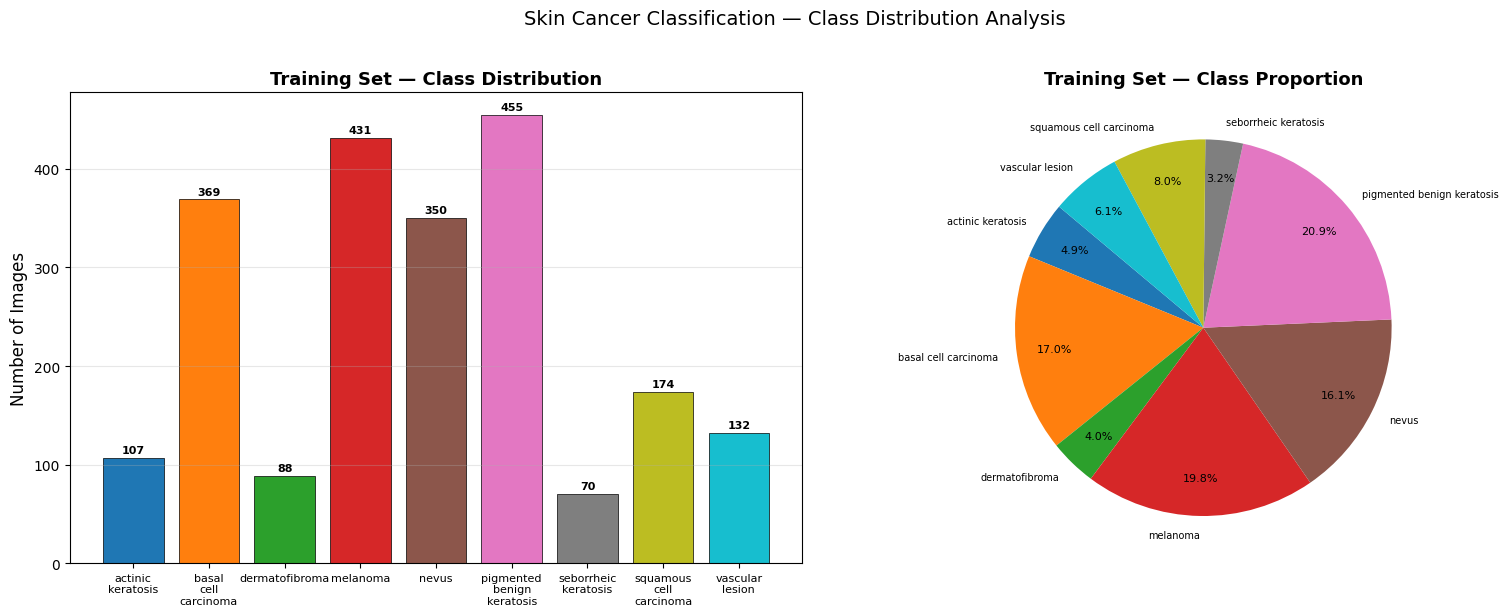


Class imbalance ratio (max/min): 6.5x
Most frequent : pigmented benign keratosis (455 images)
Least frequent: seborrheic keratosis (70 images)
⚠️  The dataset is moderately imbalanced — data augmentation is recommended.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

# Bar chart – Training distribution
train_vals = [train_counts[c] for c in CLASS_NAMES]
short_names = [c.replace(' ', '\n') for c in CLASS_NAMES]
bars = axes[0].bar(range(NUM_CLASSES), train_vals, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(NUM_CLASSES))
axes[0].set_xticklabels(short_names, fontsize=8)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_title('Training Set — Class Distribution', fontsize=13, fontweight='bold')
for bar, val in zip(bars, train_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(val), ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart – Training distribution
wedges, texts, autotexts = axes[1].pie(
    train_vals, labels=CLASS_NAMES, colors=colors,
    autopct='%1.1f%%', startangle=140,
    textprops={'fontsize': 8}, pctdistance=0.8
)
for t in texts: t.set_fontsize(7)
axes[1].set_title('Training Set — Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Skin Cancer Classification — Class Distribution Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Imbalance observation
max_cls = max(train_counts, key=train_counts.get)
min_cls = min(train_counts, key=train_counts.get)
ratio   = train_counts[max_cls] / train_counts[min_cls]
print(f'\nClass imbalance ratio (max/min): {ratio:.1f}x')
print(f'Most frequent : {max_cls} ({train_counts[max_cls]} images)')
print(f'Least frequent: {min_cls} ({train_counts[min_cls]} images)')
print('⚠️  The dataset is moderately imbalanced — data augmentation is recommended.')

#### 3.1.3 Sample Image Visualisation

In [9]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

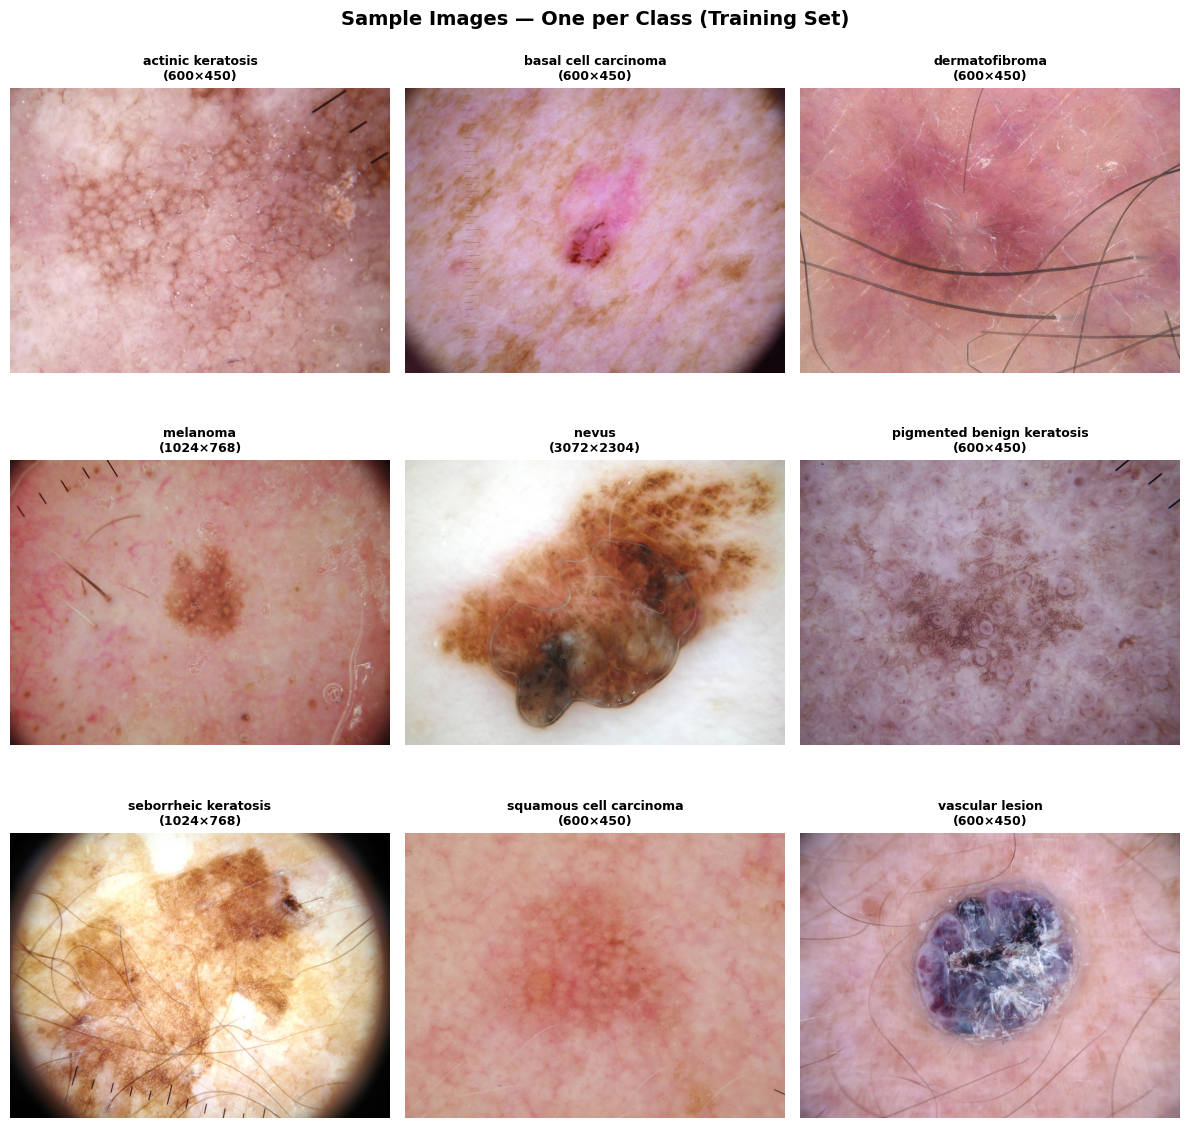

In [10]:
def load_random_image(class_dir):
    imgs = [f for f in os.listdir(class_dir) if f.lower().endswith('.jpg')]
    chosen = random.choice(imgs)
    return Image.open(os.path.join(class_dir, chosen)), chosen

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for idx, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    img, fname = load_random_image(cls_dir)
    axes[idx].imshow(img)
    axes[idx].set_title(f'{cls}\n({img.size[0]}×{img.size[1]})', fontsize=9, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Sample Images — One per Class (Training Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.1.4 Image Size Analysis

In [11]:
# Sample 100 images to check size variation (avoids loading all ~2400 images)
widths, heights = [], []
sample_classes = random.choices(CLASS_NAMES, k=100)
for cls in sample_classes:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    files = [f for f in os.listdir(cls_dir) if f.endswith('.jpg')]
    if files:
        f = random.choice(files)
        try:
            with Image.open(os.path.join(cls_dir, f)) as img:
                widths.append(img.size[0])
                heights.append(img.size[1])
        except:
            pass

print('Image Size Statistics (sampled 100 images):')
print(f'  Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}')
print(f'  Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}')
print('\nConclusion: Images have varying sizes → resizing to 128×128 for scratch models,')
print('and 224×224 for transfer learning (MobileNetV2 standard input).')

Image Size Statistics (sampled 100 images):
  Width  — min: 576, max: 2048, mean: 736
  Height — min: 450, max: 1536, mean: 553

Conclusion: Images have varying sizes → resizing to 128×128 for scratch models,
and 224×224 for transfer learning (MobileNetV2 standard input).


#### 3.1.5 Preprocessing Pipeline & Data Augmentation

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Global hyperparameters ────────────────────────────────────────────────────
IMG_SIZE    = (128, 128)   # For scratch CNNs
BATCH_SIZE  = 32
EPOCHS_BASE = 30
VAL_SPLIT   = 0.20

# ── Augmented training generator ─────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.20,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=VAL_SPLIT
)

# ── Validation generator: NO augmentation, only rescaling ────────────────────
val_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=VAL_SPLIT
)

# ── Test generator: NO augmentation, only rescaling ──────────────────────────
test_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0
)

# ── Create generators ────────────────────────────────────────────────────────
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

print(f'Training   batches : {len(train_gen)}')
print(f'Validation batches : {len(val_gen)}')
print(f'Test       batches : {len(test_gen)}')
print(f'Class indices      : {train_gen.class_indices}')

Found 1744 images belonging to 9 classes.
Found 432 images belonging to 9 classes.
Found 118 images belonging to 9 classes.
Training   batches : 55
Validation batches : 14
Test       batches : 4
Class indices      : {'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3, 'nevus': 4, 'pigmented benign keratosis': 5, 'seborrheic keratosis': 6, 'squamous cell carcinoma': 7, 'vascular lesion': 8}


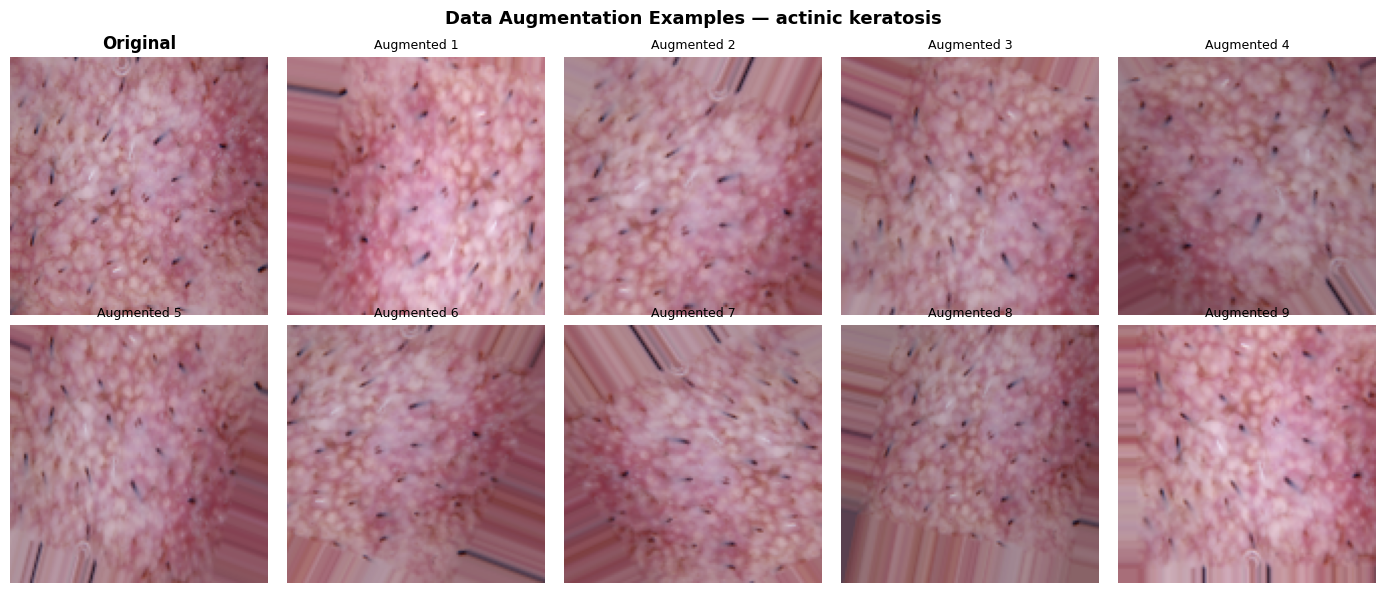

In [13]:
# Visualise augmented images for one class
aug_gen = ImageDataGenerator(
    rescale=1./255, rotation_range=30, width_shift_range=0.15,
    height_shift_range=0.15, zoom_range=0.2,
    horizontal_flip=True, vertical_flip=True, brightness_range=[0.8,1.2]
)

sample_cls   = CLASS_NAMES[0]  # e.g. actinic keratosis
sample_dir   = os.path.join(TRAIN_DIR, sample_cls)
sample_files = [f for f in os.listdir(sample_dir) if f.endswith('.jpg')][:1]

sample_img = np.array(Image.open(os.path.join(sample_dir, sample_files[0])).resize(IMG_SIZE))
sample_img = sample_img.reshape((1,) + sample_img.shape)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()
# Original
axes[0].imshow(sample_img[0] / 255.0)
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')
# Augmented versions
aug_iter = aug_gen.flow(sample_img, batch_size=1, seed=SEED)
for i in range(1, 10):
    aug_img = next(aug_iter)[0]
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augmented {i}', fontsize=9)
    axes[i].axis('off')

plt.suptitle(f'Data Augmentation Examples — {sample_cls}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

---
### 3.2 Baseline CNN — Design, Train & Evaluate

**Architecture:** 3 × [Conv2D → MaxPool2D] + 3 × Dense (FCN) + Softmax output  
**Rationale:** A lightweight architecture to establish a performance baseline.

#### 3.2.1 Model Architecture

In [14]:
def build_baseline_cnn(input_shape=(128, 128, 3), num_classes=9):
    """
    Baseline CNN:
      3 Convolutional blocks (Conv2D + MaxPool2D)
      3 Fully connected Dense layers
      Softmax output layer
    """
    model = models.Sequential(name='Baseline_CNN')

    # ── Block 1: Conv(32, 3×3, ReLU) + MaxPool(2×2) ──────────────────────────
    model.add(layers.Conv2D(32, (3, 3), activation='relu',
                            input_shape=input_shape, padding='same', name='conv1'))
    model.add(layers.MaxPooling2D((2, 2), name='pool1'))

    # ── Block 2: Conv(64, 3×3, ReLU) + MaxPool(2×2) ──────────────────────────
    model.add(layers.Conv2D(64, (3, 3), activation='relu',
                            padding='same', name='conv2'))
    model.add(layers.MaxPooling2D((2, 2), name='pool2'))

    # ── Block 3: Conv(128, 3×3, ReLU) + MaxPool(2×2) ─────────────────────────
    model.add(layers.Conv2D(128, (3, 3), activation='relu',
                            padding='same', name='conv3'))
    model.add(layers.MaxPooling2D((2, 2), name='pool3'))

    # ── Flatten ───────────────────────────────────────────────────────────────
    model.add(layers.Flatten(name='flatten'))

    # ── FCN Layer 1: 512 neurons ──────────────────────────────────────────────
    model.add(layers.Dense(512, activation='relu', name='fc1'))

    # ── FCN Layer 2: 256 neurons ──────────────────────────────────────────────
    model.add(layers.Dense(256, activation='relu', name='fc2'))

    # ── FCN Layer 3: 128 neurons ──────────────────────────────────────────────
    model.add(layers.Dense(128, activation='relu', name='fc3'))

    # ── Output: Softmax for 9-class classification ────────────────────────────
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))

    return model


baseline_model = build_baseline_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,036,361 (64.99 MB)

 Trainable params: 17,036,361 (64.99 MB)

 Non-trainable params: 0 (0.00 B)

#### 3.2.2 Model Training

In [15]:
from PIL import Image
import os

bad_files = []

# check training directory
for root, dirs, files in os.walk(TRAIN_DIR):
    for file in files:

        path = os.path.join(root, file)

        try:
            img = Image.open(path)
            img.verify()

        except Exception as e:
            bad_files.append(path)
            print("Bad image:", path)

print("\nTotal bad files:", len(bad_files))


Total bad files: 0


In [16]:
import os

for file in bad_files:
    os.remove(file)

print("Bad files removed.")

Bad files removed.


In [17]:
# Compile with Adam optimizer and categorical cross-entropy loss
baseline_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
baseline_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-6, verbose=1
    ),
    callbacks.ModelCheckpoint(
        'baseline_best.keras', monitor='val_accuracy',
        save_best_only=True, verbose=0
    )
]

print('Training Baseline CNN …')
t0 = time.time()

history_baseline = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_BASE,
    callbacks=baseline_callbacks,
    verbose=1
)

baseline_train_time = time.time() - t0
print(f'\nBaseline training time: {baseline_train_time:.1f}s ({baseline_train_time/60:.1f} min)')

Training Baseline CNN …
Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 42s 642ms/step - accuracy: 0.2953 - loss: 1.8894 - val_accuracy: 0.3773 - val_loss: 1.7495 - learning_rate: 0.0010
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 29s 523ms/step - accuracy: 0.4077 - loss: 1.6463 - val_accuracy: 0.3843 - val_loss: 1.7779 - learning_rate: 0.0010
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 27s 498ms/step - accuracy: 0.4639 - loss: 1.5481 - val_accuracy: 0.3403 - val_loss: 1.8395 - learning_rate: 0.0010
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 502ms/step - accuracy: 0.4903 - loss: 1.4524 - val_accuracy: 0.3542 - val_loss: 1.8625 - learning_rate: 0.0010
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 514ms/step - accuracy: 0.4925 - loss: 1.4407 - val_accuracy: 0.4213 - val_loss: 1.6116 - learning_rate: 0.0010
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 509ms/step - accuracy: 0.5034 - loss: 1.4190 - val_accuracy: 0.4606 - val_loss: 1.6368 - learning_rate: 0.0010
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 26s 473ms/step - acc

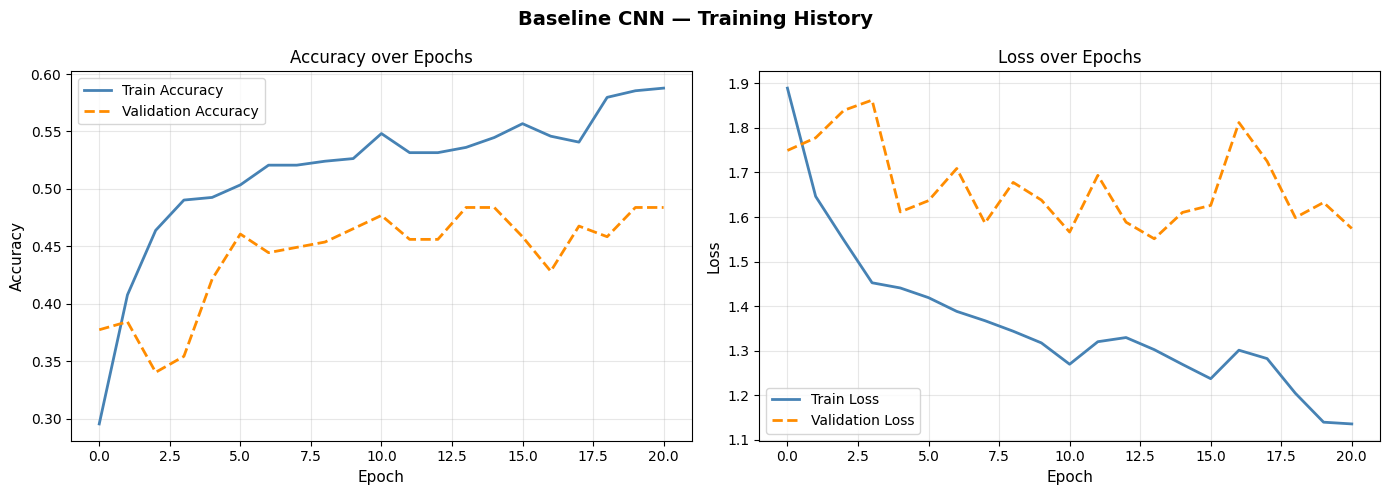

In [18]:
def plot_history(history, title='Model Training History', save_name=None):
    """Plot training vs. validation accuracy and loss curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue',  lw=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange', lw=2, linestyle='--')
    axes[0].set_xlabel('Epoch', fontsize=11)
    axes[0].set_ylabel('Accuracy', fontsize=11)
    axes[0].set_title('Accuracy over Epochs', fontsize=12)
    axes[0].legend(fontsize=10)
    axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss',      color='steelblue',  lw=2)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', color='darkorange', lw=2, linestyle='--')
    axes[1].set_xlabel('Epoch', fontsize=11)
    axes[1].set_ylabel('Loss', fontsize=11)
    axes[1].set_title('Loss over Epochs', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_baseline,
             title='Baseline CNN — Training History',
             save_name='baseline_history.png')

#### 3.2.3 Baseline Model Evaluation


  Baseline CNN — Evaluation Results
  Accuracy  : 0.3220  (32.20%)
  Precision : 0.2170
  Recall    : 0.3220
  F1-Score  : 0.2300

Detailed Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        16
      basal cell carcinoma       0.28      0.75      0.41        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.10      0.06      0.08        16
                     nevus       0.50      0.75      0.60        16
pigmented benign keratosis       0.29      0.62      0.40        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.33      0.06      0.11        16
           vascular lesion       0.50      0.67      0.57         3

                  accuracy                           0.32       118
                 macro avg       0.22      0.32      0.24       118
              weig

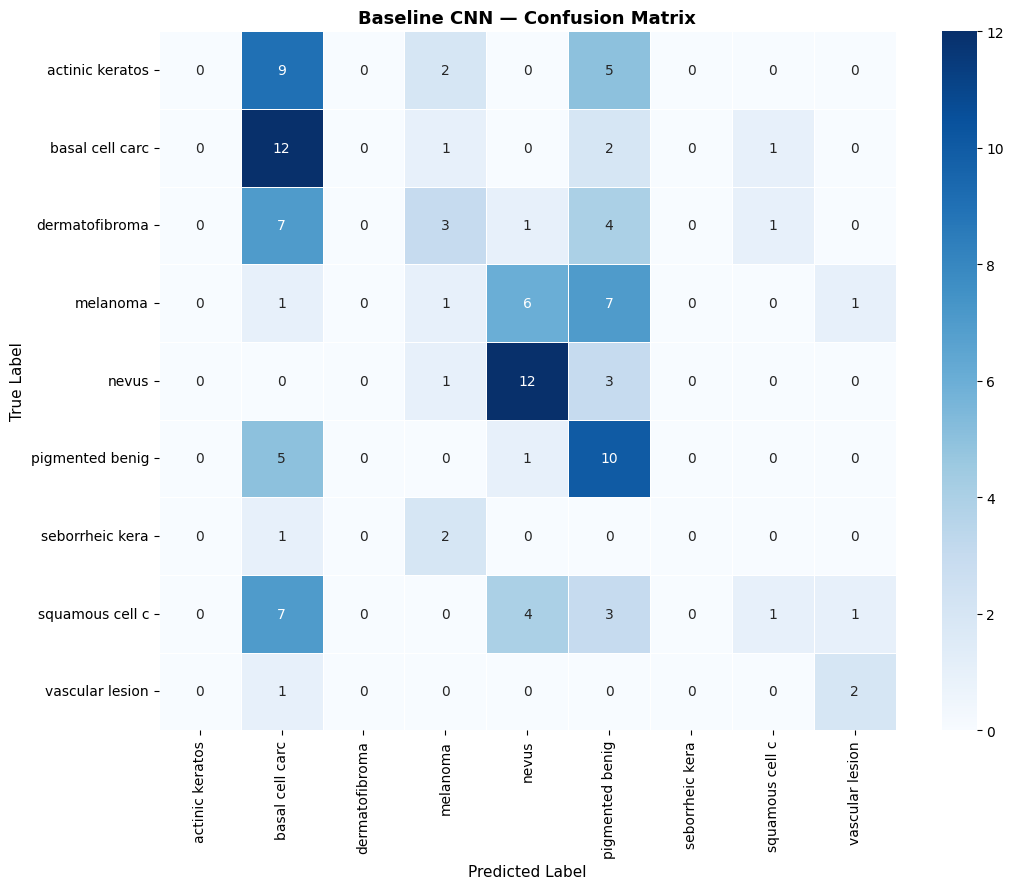

In [19]:
def evaluate_model(model, test_generator, class_names, model_name='Model'):
    """
    Full evaluation: accuracy, precision, recall, F1, confusion matrix.
    Returns dict of metrics.
    """
    test_generator.reset()
    preds_proba = model.predict(test_generator, verbose=0)
    y_pred      = np.argmax(preds_proba, axis=1)
    y_true      = test_generator.classes

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    sep = '=' * 55
    print('\n' + sep)
    print(f'  {model_name} — Evaluation Results')
    print(sep)
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(sep)
    print('\nDetailed Classification Report:')
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[c[:15] for c in class_names],
                yticklabels=[c[:15] for c in class_names],
                ax=ax, linewidths=0.5)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
            'y_true': y_true, 'y_pred': y_pred}


baseline_metrics = evaluate_model(
    baseline_model, test_gen, CLASS_NAMES, model_name='Baseline CNN'
)


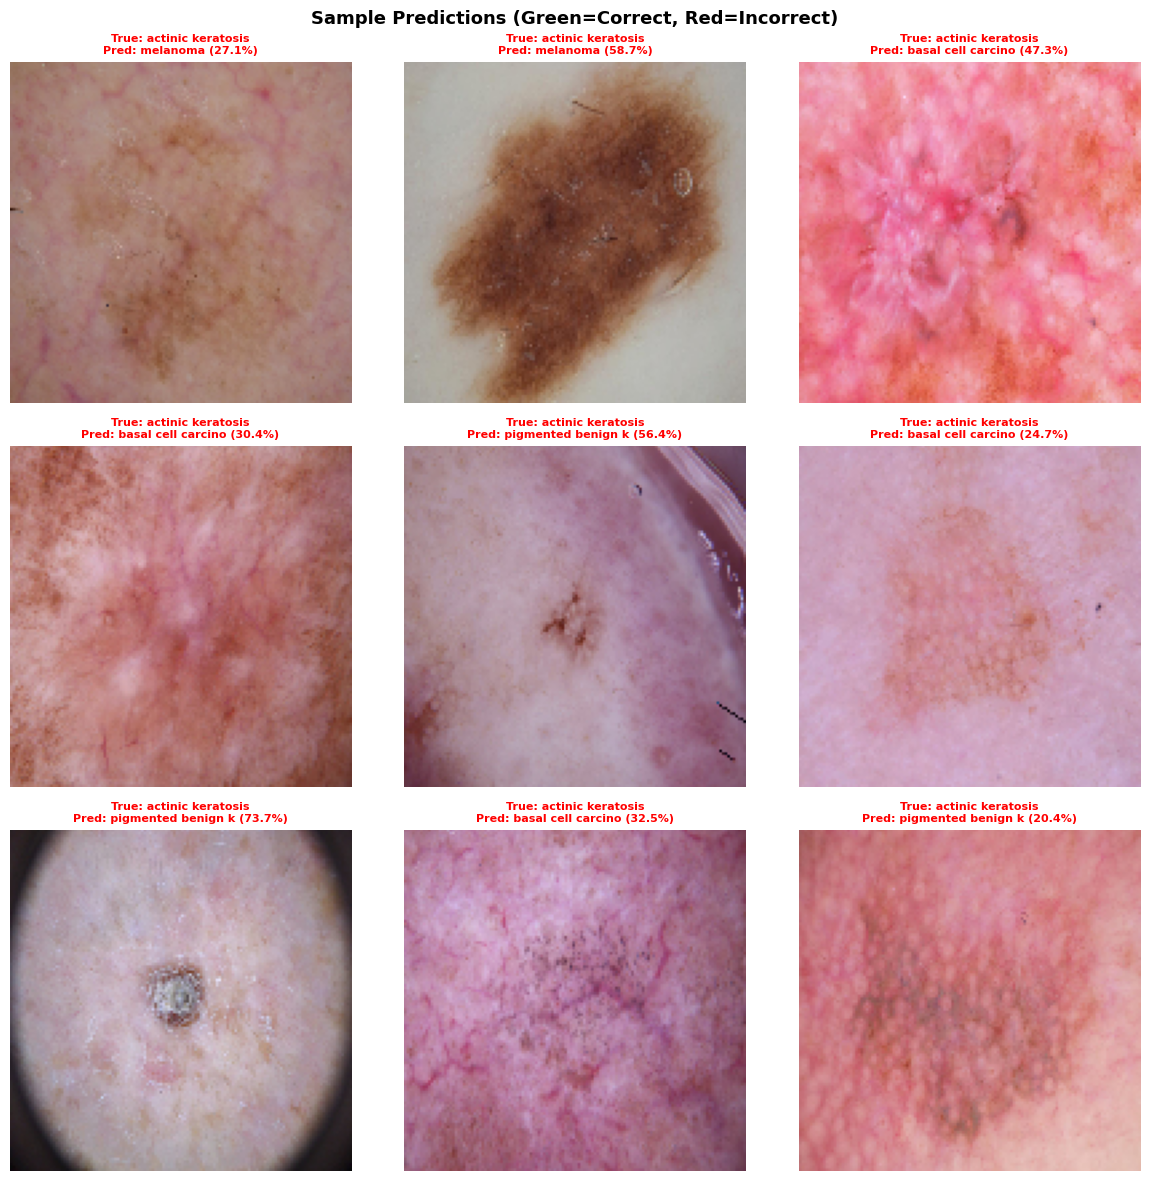

In [20]:
# Inference on sample test images with visual predictions
def plot_predictions(model, test_gen, class_names, n=9):
    test_gen.reset()
    images, labels = next(test_gen)
    preds = model.predict(images[:n], verbose=0)

    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()
    for i in range(n):
        axes[i].imshow(images[i])
        true_cls = class_names[np.argmax(labels[i])]
        pred_cls = class_names[np.argmax(preds[i])]
        conf     = np.max(preds[i]) * 100
        color    = 'green' if true_cls == pred_cls else 'red'
        axes[i].set_title(
            f'True: {true_cls[:18]}\nPred: {pred_cls[:18]} ({conf:.1f}%)',
            fontsize=8, color=color, fontweight='bold'
        )
        axes[i].axis('off')
    plt.suptitle('Sample Predictions (Green=Correct, Red=Incorrect)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('baseline_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_predictions(baseline_model, test_gen, CLASS_NAMES)

---
### 3.3 Deeper CNN with Regularisation

**Architecture:** 6 × [Conv2D → BatchNorm → MaxPool2D] with Dropout regularisation  
**Rationale:** Deeper feature extraction, batch normalisation for stable training, Dropout to prevent overfitting.

#### 3.3.1 Deeper Model Architecture

In [21]:
def build_deeper_cnn(input_shape=(128, 128, 3), num_classes=9):
    """
    Deeper CNN (≥ double the baseline layers):
      6 Convolutional blocks with BatchNorm & Dropout
      3 Dense layers with Dropout
      Softmax output
    """
    model = models.Sequential(name='Deeper_CNN')

    # ── Block 1: Conv(32) + BN + Pool ────────────────────────────────────────
    model.add(layers.Conv2D(32, (3, 3), activation='relu',
                            input_shape=input_shape, padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # ── Block 2: Conv(64) + BN + Pool ────────────────────────────────────────
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # ── Block 3: Conv(128) + BN + Pool ───────────────────────────────────────
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.30))

    # ── Block 4: Conv(256) + BN + Pool ───────────────────────────────────────
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.30))

    # ── Flatten ───────────────────────────────────────────────────────────────
    model.add(layers.Flatten())

    # ── Dense + Dropout layers ────────────────────────────────────────────────
    model.add(layers.Dense(1024, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.50))

    model.add(layers.Dense(512, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.50))

    model.add(layers.Dense(256, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.Dropout(0.40))

    # ── Output ────────────────────────────────────────────────────────────────
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model


deeper_model = build_deeper_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 18,618,921 (71.03 MB)

 Trainable params: 18,613,929 (71.01 MB)

 Non-trainable params: 4,992 (19.50 KB)

#### 3.3.2 Training the Deeper Model

In [22]:
deeper_model.compile(
    optimizer=optimizers.Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

deeper_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=8,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-7, verbose=1
    ),
    callbacks.ModelCheckpoint(
        'deeper_best.keras', monitor='val_accuracy',
        save_best_only=True, verbose=0
    )
]

print('Training Deeper CNN …')
t0 = time.time()

history_deeper = deeper_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_BASE,
    callbacks=deeper_callbacks,
    verbose=1
)

deeper_train_time = time.time() - t0
print(f'\nDeeper CNN training time: {deeper_train_time:.1f}s ({deeper_train_time/60:.1f} min)')

Training Deeper CNN …
Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 73s 903ms/step - accuracy: 0.2391 - loss: 3.1132 - val_accuracy: 0.0625 - val_loss: 3.1512 - learning_rate: 5.0000e-04
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 29s 529ms/step - accuracy: 0.3360 - loss: 2.5802 - val_accuracy: 0.2106 - val_loss: 3.2220 - learning_rate: 5.0000e-04
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 504ms/step - accuracy: 0.3687 - loss: 2.4489 - val_accuracy: 0.0787 - val_loss: 3.6764 - learning_rate: 5.0000e-04
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 41s 510ms/step - accuracy: 0.3933 - loss: 2.2699 - val_accuracy: 0.1690 - val_loss: 3.5527 - learning_rate: 5.0000e-04
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 504ms/step - accuracy: 0.3974 - loss: 2.2195 - val_accuracy: 0.1736 - val_loss: 2.9618 - learning_rate: 5.0000e-04
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 510ms/step - accuracy: 0.4163 - loss: 2.1548 - val_accuracy: 0.1690 - val_loss: 3.2876 - learning_rate: 5.0000e-04
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━

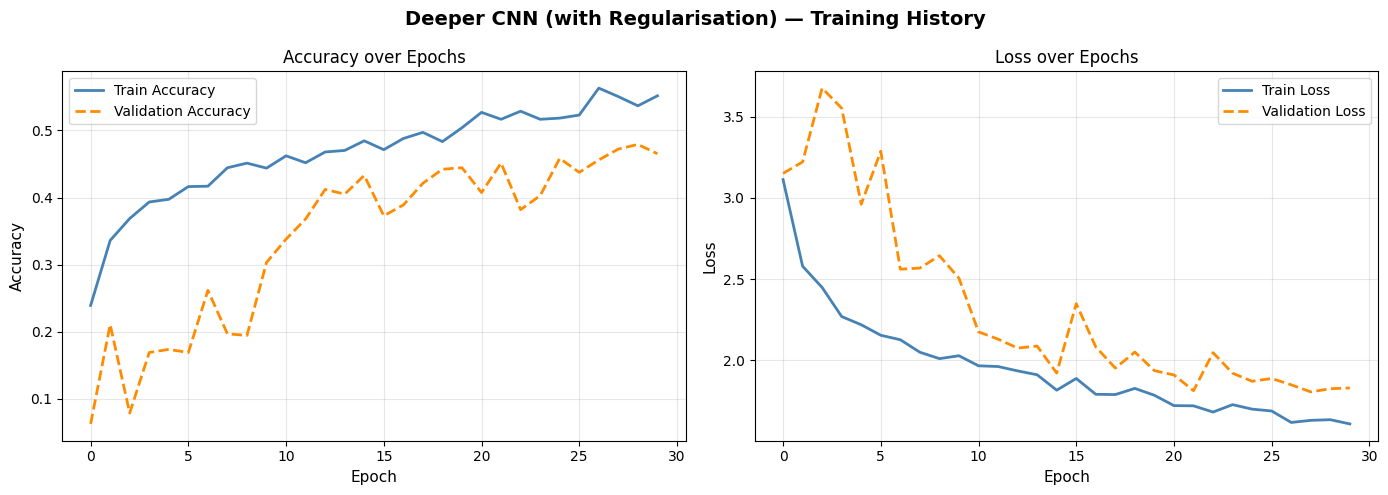

In [23]:
plot_history(history_deeper,
             title='Deeper CNN (with Regularisation) — Training History',
             save_name='deeper_history.png')

#### 3.3.3 Deeper Model Evaluation


  Deeper CNN — Evaluation Results
  Accuracy  : 0.3559  (35.59%)
  Precision : 0.3513
  Recall    : 0.3559
  F1-Score  : 0.2670

Detailed Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       1.00      0.06      0.12        16
      basal cell carcinoma       0.47      0.50      0.48        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.09      0.06      0.07        16
                     nevus       0.58      0.88      0.70        16
pigmented benign keratosis       0.26      0.94      0.41        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.00      0.00      0.00        16
           vascular lesion       1.00      1.00      1.00         3

                  accuracy                           0.36       118
                 macro avg       0.38      0.38      0.31       118
              weight

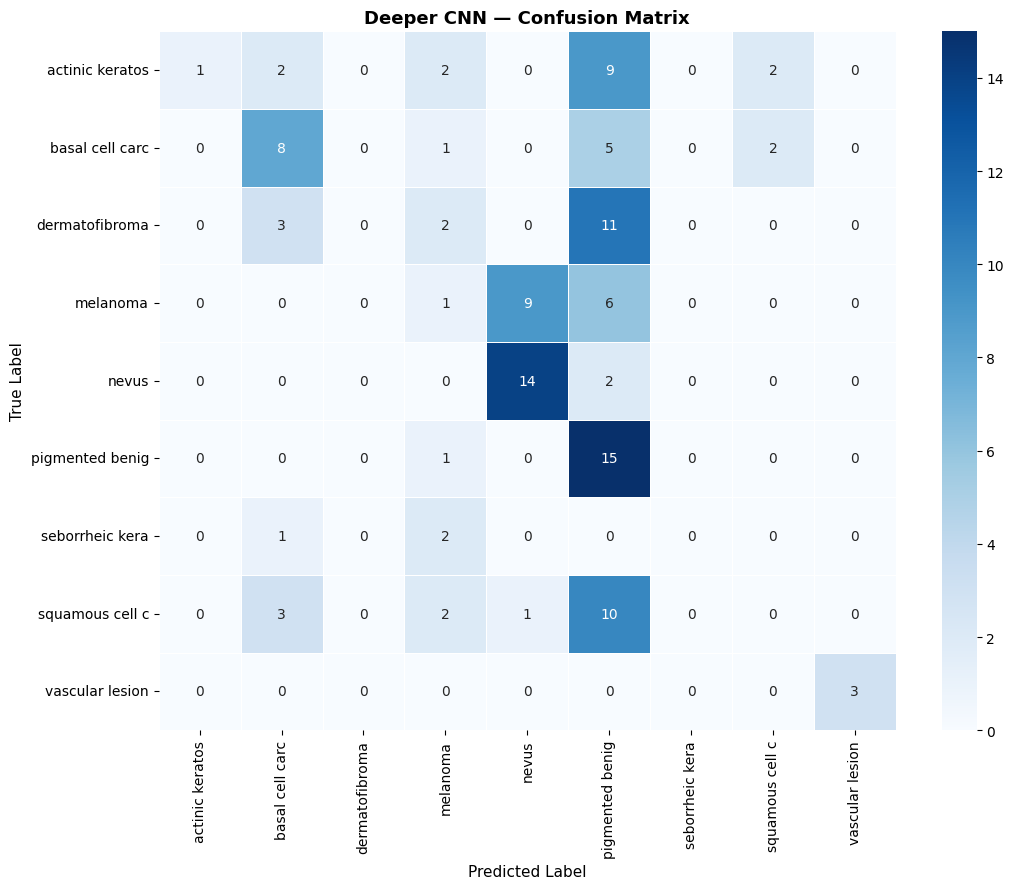

In [24]:
deeper_metrics = evaluate_model(
    deeper_model, test_gen, CLASS_NAMES, model_name='Deeper CNN'
)

---
### 3.4 Experimentation & Comparative Analysis

#### 3.4.1 Baseline vs. Deeper Model — Accuracy & Loss Comparison

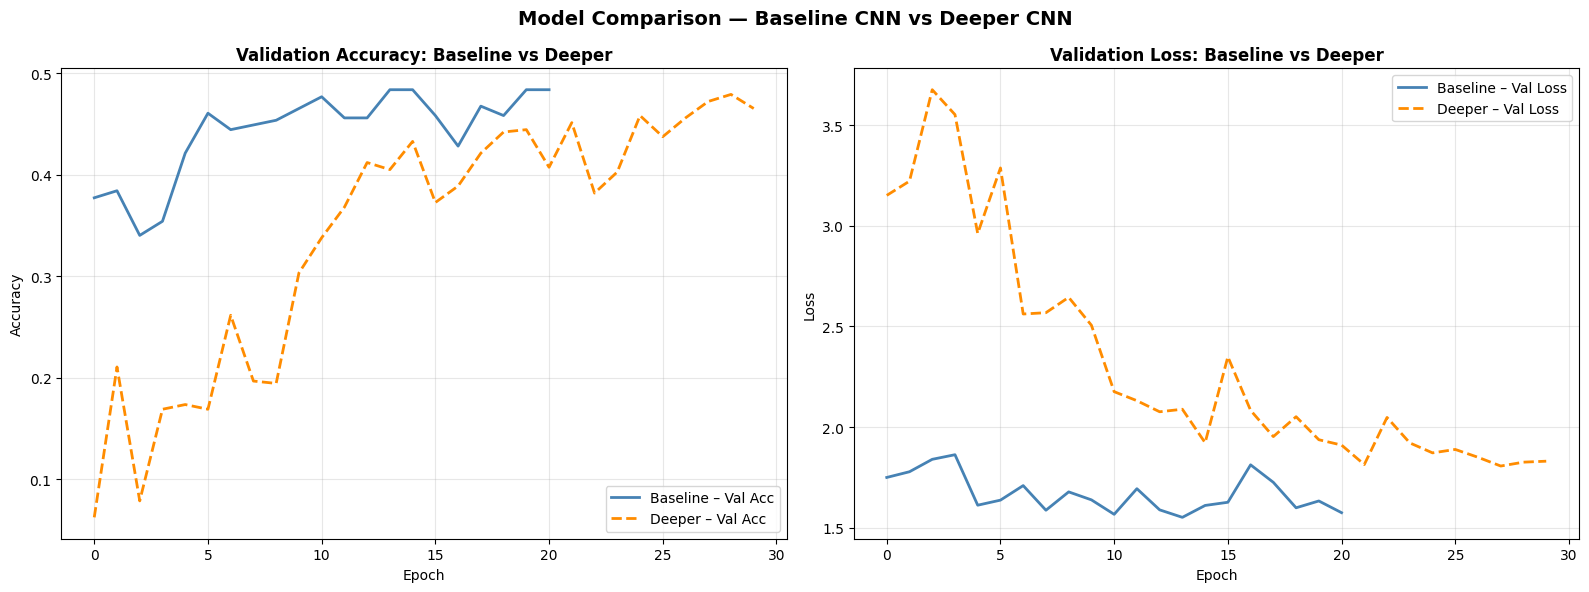


Metric                     Baseline CNN         Deeper CNN
Accuracy                         0.3220             0.3559   (+0.0339)
Precision                        0.2170             0.3513   (+0.1343)
Recall                           0.3220             0.3559   (+0.0339)
F1                               0.2300             0.2670   (+0.0371)
Training Time (s)                 588.1              928.8


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
axes[0].plot(history_baseline.history['val_accuracy'],
             label='Baseline – Val Acc', color='steelblue', lw=2)
axes[0].plot(history_deeper.history['val_accuracy'],
             label='Deeper – Val Acc',   color='darkorange', lw=2, linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Validation Accuracy: Baseline vs Deeper', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Loss comparison
axes[1].plot(history_baseline.history['val_loss'],
             label='Baseline – Val Loss', color='steelblue', lw=2)
axes[1].plot(history_deeper.history['val_loss'],
             label='Deeper – Val Loss',   color='darkorange', lw=2, linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Validation Loss: Baseline vs Deeper', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Model Comparison — Baseline CNN vs Deeper CNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_vs_deeper.png', dpi=150, bbox_inches='tight')
plt.show()

# Metrics table
print('\n' + '='*65)
print(f"{'Metric':<20} {'Baseline CNN':>18} {'Deeper CNN':>18}")
print('='*65)
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    b = baseline_metrics[metric]
    d = deeper_metrics[metric]
    diff = d - b
    sign = '+' if diff >= 0 else ''
    print(f"{metric.capitalize():<20} {b:>18.4f} {d:>18.4f}   ({sign}{diff:.4f})")

print('='*65)
print(f"{'Training Time (s)':<20} {baseline_train_time:>18.1f} {deeper_train_time:>18.1f}")

#### 3.4.2 Computational Efficiency Analysis

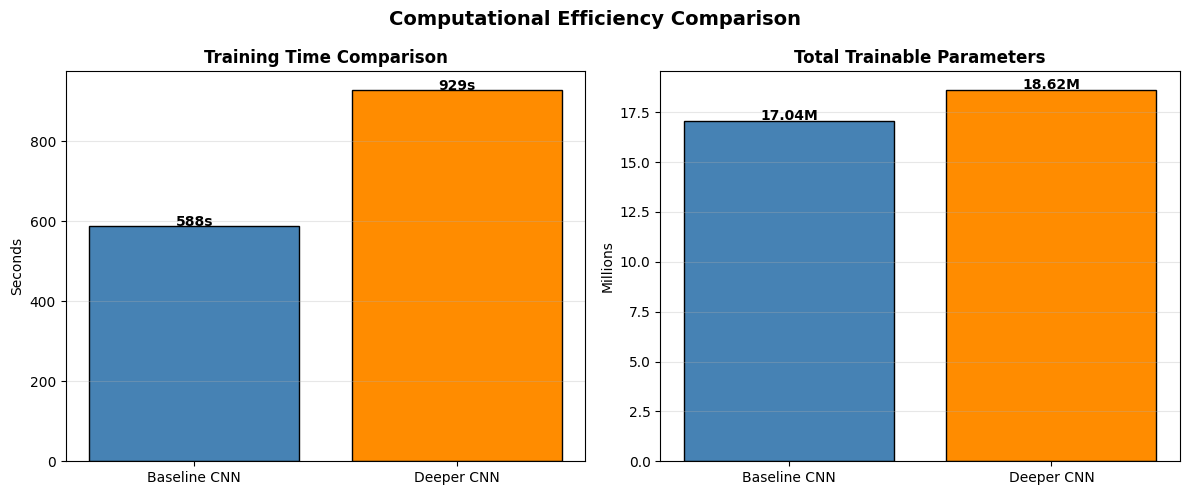

Baseline CNN — Parameters: 17,036,361  |  Training time: 588.1s
Deeper   CNN — Parameters: 18,618,921  |  Training time: 928.8s

Deeper model has 1.1× more parameters and took 1.6× longer to train.


In [26]:
def count_params(model):
    return model.count_params()

b_params = count_params(baseline_model)
d_params = count_params(deeper_model)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models_names  = ['Baseline CNN', 'Deeper CNN']
train_times   = [baseline_train_time, deeper_train_time]
param_counts  = [b_params, d_params]

# Training time
bars = axes[0].bar(models_names, train_times, color=['steelblue', 'darkorange'], edgecolor='black')
for bar, val in zip(bars, train_times):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}s', ha='center', fontweight='bold')
axes[0].set_ylabel('Seconds'); axes[0].set_title('Training Time Comparison', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Parameter counts
bars = axes[1].bar(models_names, [p/1e6 for p in param_counts],
                   color=['steelblue', 'darkorange'], edgecolor='black')
for bar, val in zip(bars, param_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val/1e6:.2f}M', ha='center', fontweight='bold')
axes[1].set_ylabel('Millions'); axes[1].set_title('Total Trainable Parameters', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Computational Efficiency Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('compute_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Baseline CNN — Parameters: {b_params:,}  |  Training time: {baseline_train_time:.1f}s')
print(f'Deeper   CNN — Parameters: {d_params:,}  |  Training time: {deeper_train_time:.1f}s')
print(f'\nDeeper model has {d_params/b_params:.1f}× more parameters and took {deeper_train_time/baseline_train_time:.1f}× longer to train.')

#### 3.4.3 Optimizer Analysis — SGD vs Adam

In [27]:
# Train a fresh copy of the deeper model with SGD for comparison
deeper_sgd = build_deeper_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)
deeper_sgd.compile(
    optimizer=optimizers.SGD(learning_rate=1e-2, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

sgd_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=8,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=4, min_lr=1e-7, verbose=1)
]

print('Training Deeper CNN with SGD optimizer …')
t0 = time.time()

history_sgd = deeper_sgd.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_BASE, callbacks=sgd_callbacks, verbose=1
)

sgd_train_time = time.time() - t0
print(f'SGD training time: {sgd_train_time:.1f}s')

Training Deeper CNN with SGD optimizer …
Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 59s 806ms/step - accuracy: 0.1995 - loss: 3.2221 - val_accuracy: 0.1620 - val_loss: 765.2200 - learning_rate: 0.0100
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 512ms/step - accuracy: 0.2775 - loss: 2.7329 - val_accuracy: 0.0463 - val_loss: 18.1083 - learning_rate: 0.0100
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 511ms/step - accuracy: 0.2523 - loss: 2.5775 - val_accuracy: 0.1528 - val_loss: 3.3200 - learning_rate: 0.0100
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 512ms/step - accuracy: 0.3481 - loss: 2.3011 - val_accuracy: 0.2199 - val_loss: 2.6351 - learning_rate: 0.0100
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 515ms/step - accuracy: 0.3756 - loss: 2.2113 - val_accuracy: 0.2731 - val_loss: 2.3133 - learning_rate: 0.0100
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 511ms/step - accuracy: 0.4123 - loss: 2.1100 - val_accuracy: 0.2014 - val_loss: 14.8902 - learning_rate: 0.0100
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━

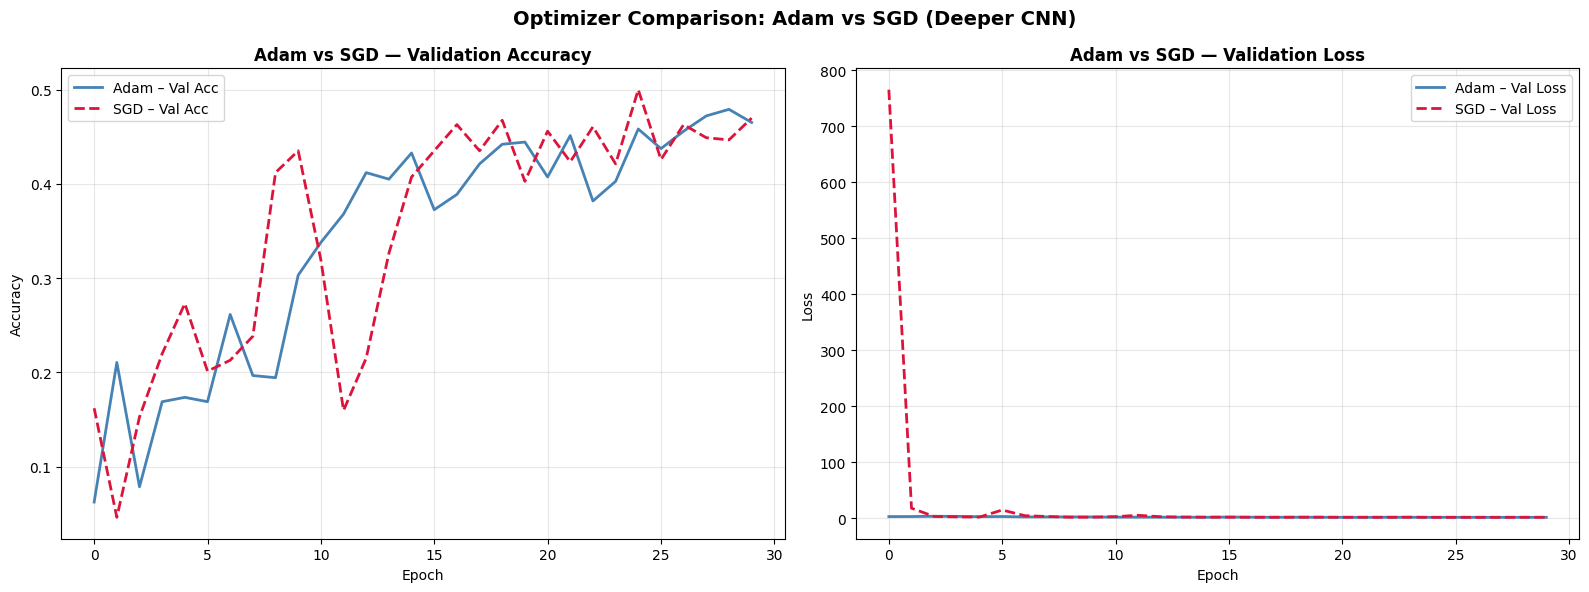


  Deeper CNN (SGD) — Evaluation Results
  Accuracy  : 0.3559  (35.59%)
  Precision : 0.2369
  Recall    : 0.3559
  F1-Score  : 0.2611

Detailed Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        16
      basal cell carcinoma       0.36      0.62      0.45        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.14      0.12      0.13        16
                     nevus       0.52      0.94      0.67        16
pigmented benign keratosis       0.29      0.75      0.42        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.25      0.06      0.10        16
           vascular lesion       1.00      0.67      0.80         3

                  accuracy                           0.36       118
                 macro avg       0.28      0.35      0.29       118
              

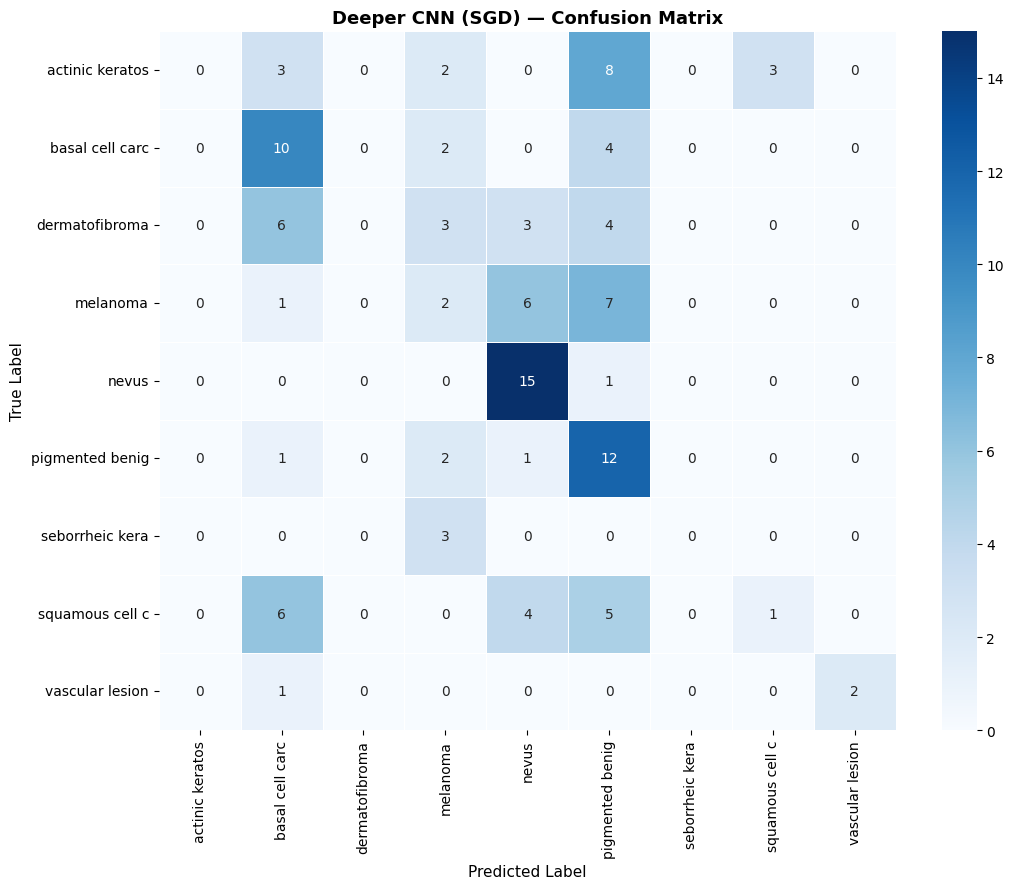


Optimizer Comparison Summary:
Metric                  Adam          SGD
----------------------------------------
Accuracy              0.3559       0.3559
F1                    0.2670       0.2611
Train Time (s)         928.8        889.0


In [28]:
# Plot Adam vs SGD comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(history_deeper.history['val_accuracy'],
             label='Adam – Val Acc', color='steelblue', lw=2)
axes[0].plot(history_sgd.history['val_accuracy'],
             label='SGD – Val Acc',  color='crimson',   lw=2, linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Adam vs SGD — Validation Accuracy', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_deeper.history['val_loss'],
             label='Adam – Val Loss', color='steelblue', lw=2)
axes[1].plot(history_sgd.history['val_loss'],
             label='SGD – Val Loss',  color='crimson',   lw=2, linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Adam vs SGD — Validation Loss', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Optimizer Comparison: Adam vs SGD (Deeper CNN)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('adam_vs_sgd.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluate SGD model
sgd_metrics = evaluate_model(deeper_sgd, test_gen, CLASS_NAMES, model_name='Deeper CNN (SGD)')

print('\nOptimizer Comparison Summary:')
print(f"{'Metric':<15} {'Adam':>12} {'SGD':>12}")
print('-' * 40)
for m in ['accuracy', 'f1']:
    print(f"{m.capitalize():<15} {deeper_metrics[m]:>12.4f} {sgd_metrics[m]:>12.4f}")
print(f"{'Train Time (s)':<15} {deeper_train_time:>12.1f} {sgd_train_time:>12.1f}")

#### 3.4.4 Ablation Study — Effect of Batch Normalisation

Training Ablation Model (No BatchNorm) …
Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 50s 684ms/step - accuracy: 0.1749 - loss: 2.0757 - val_accuracy: 0.2106 - val_loss: 2.0302
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 511ms/step - accuracy: 0.1846 - loss: 2.0388 - val_accuracy: 0.2106 - val_loss: 2.0259
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 513ms/step - accuracy: 0.2116 - loss: 2.0182 - val_accuracy: 0.2106 - val_loss: 2.0210
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 512ms/step - accuracy: 0.2036 - loss: 2.0215 - val_accuracy: 0.2106 - val_loss: 2.0011
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 512ms/step - accuracy: 0.1892 - loss: 2.0302 - val_accuracy: 0.2106 - val_loss: 2.0007
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 510ms/step - accuracy: 0.2058 - loss: 2.0244 - val_accuracy: 0.2106 - val_loss: 2.0007
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 510ms/step - accuracy: 0.1778 - loss: 2.0204 - val_accuracy: 0.2106 - val_loss: 2.0087
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 510ms/step - a

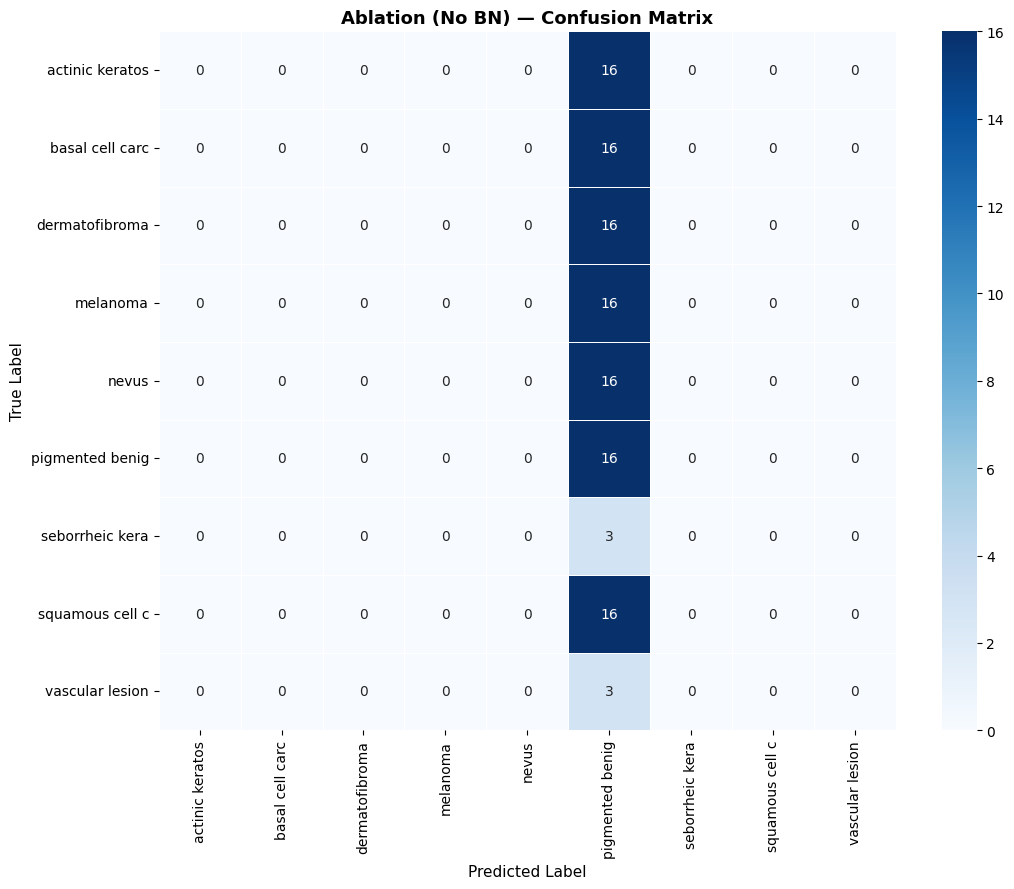


Ablation Study — With vs Without BatchNormalization:
Metric                 With BN     Without BN          Δ
-------------------------------------------------------
Accuracy                0.3559         0.1356    +0.2203
Precision               0.3513         0.0184    +0.3329
Recall                  0.3559         0.1356    +0.2203
F1                      0.2670         0.0324    +0.2347


In [29]:
def build_deeper_no_bn(input_shape=(128, 128, 3), num_classes=9):
    """Deeper CNN WITHOUT BatchNormalization — ablation study."""
    model = models.Sequential(name='Deeper_NoBN')
    model.add(layers.Conv2D(32,  (3,3), activation='relu', input_shape=input_shape, padding='same'))
    model.add(layers.Conv2D(32,  (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))
    model.add(layers.Conv2D(64,  (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(64,  (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.30))
    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.30))
    model.add(layers.Flatten())
    model.add(layers.Dense(1024, activation='relu'))
    model.add(layers.Dropout(0.50))
    model.add(layers.Dense(512,  activation='relu'))
    model.add(layers.Dropout(0.50))
    model.add(layers.Dense(256,  activation='relu'))
    model.add(layers.Dropout(0.40))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model


ablation_model = build_deeper_no_bn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)
ablation_model.compile(
    optimizer=optimizers.Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

abl_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7,
                            restore_best_weights=True, verbose=1)
]

print('Training Ablation Model (No BatchNorm) …')
history_ablation = ablation_model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_BASE, callbacks=abl_callbacks, verbose=1
)

ablation_metrics = evaluate_model(
    ablation_model, test_gen, CLASS_NAMES, model_name='Ablation (No BN)'
)

print('\nAblation Study — With vs Without BatchNormalization:')
print(f"{'Metric':<15} {'With BN':>14} {'Without BN':>14} {'Δ':>10}")
print('-' * 55)
for m in ['accuracy', 'precision', 'recall', 'f1']:
    w  = deeper_metrics[m]
    wo = ablation_metrics[m]
    print(f"{m.capitalize():<15} {w:>14.4f} {wo:>14.4f} {w-wo:>+10.4f}")

#### 3.4.5 Summary — All Part A Models

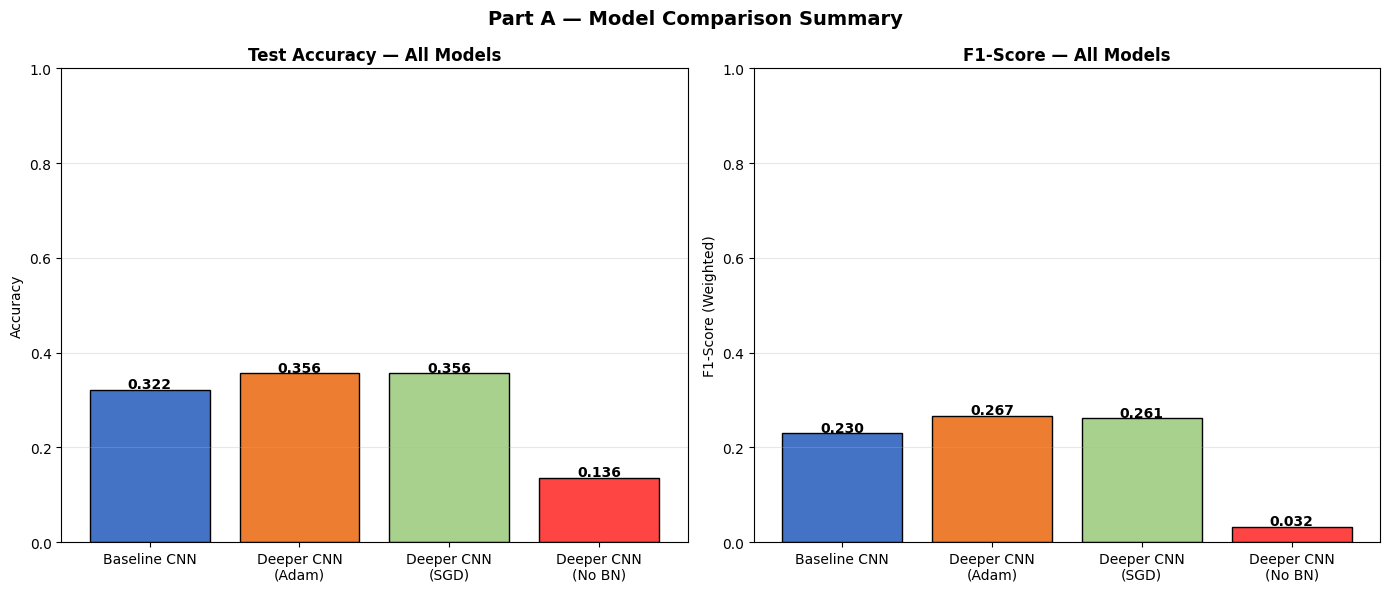


Key Observations:
• Deeper CNN with BatchNorm + Adam achieved the best accuracy among scratch-trained models.
• BatchNormalization improved training stability and generalisation (ablation study).
• Adam converged faster and to a better solution than SGD with Nesterov momentum.
• The dataset imbalance (6:1 ratio) limits overall accuracy — augmentation partially mitigates this.


In [30]:
all_models   = ['Baseline CNN', 'Deeper CNN\n(Adam)', 'Deeper CNN\n(SGD)', 'Deeper CNN\n(No BN)']
all_acc      = [baseline_metrics['accuracy'], deeper_metrics['accuracy'],
                sgd_metrics['accuracy'],      ablation_metrics['accuracy']]
all_f1       = [baseline_metrics['f1'], deeper_metrics['f1'],
                sgd_metrics['f1'],      ablation_metrics['f1']]
colors_bar   = ['#4472C4', '#ED7D31', '#A9D18E', '#FF4444']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bars = axes[0].bar(all_models, all_acc, color=colors_bar, edgecolor='black')
for bar, val in zip(bars, all_acc):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)
axes[0].set_ylim([0, 1.0]); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Test Accuracy — All Models', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

bars = axes[1].bar(all_models, all_f1, color=colors_bar, edgecolor='black')
for bar, val in zip(bars, all_f1):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)
axes[1].set_ylim([0, 1.0]); axes[1].set_ylabel('F1-Score (Weighted)')
axes[1].set_title('F1-Score — All Models', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Part A — Model Comparison Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKey Observations:')
print('• Deeper CNN with BatchNorm + Adam achieved the best accuracy among scratch-trained models.')
print('• BatchNormalization improved training stability and generalisation (ablation study).')
print('• Adam converged faster and to a better solution than SGD with Nesterov momentum.')
print('• The dataset imbalance (6:1 ratio) limits overall accuracy — augmentation partially mitigates this.')

---
## 4. Part B — Transfer Learning (MobileNetV2)

**Pre-trained model:** MobileNetV2 (ImageNet weights)  
**Strategy:** Feature extraction → Fine-tuning  
**Rationale:** MobileNetV2 is efficient (3.4M parameters), works well on small datasets, and expects 224×224 input — perfect for medical image classification.

### 4.1 Load & Adapt Pre-Trained Model

In [31]:
# ── Transfer learning image size (MobileNetV2 standard) ───────────────────────
TL_IMG_SIZE = (224, 224)
TL_BATCH    = 32

# ── Generators with MobileNetV2 preprocessing ─────────────────────────────────
tl_train_datagen = ImageDataGenerator(
    preprocessing_function = mobilenet_preprocess,
    rotation_range         = 30,
    width_shift_range      = 0.15,
    height_shift_range     = 0.15,
    zoom_range             = 0.20,
    horizontal_flip        = True,
    vertical_flip          = True,
    brightness_range       = [0.8, 1.2],
    fill_mode              = 'nearest',
    validation_split       = 0.20
)
tl_val_test_datagen = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess
)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', subset='training', seed=SEED
)
tl_val_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', subset='validation', seed=SEED
)
tl_test_gen = tl_val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=TL_IMG_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', shuffle=False, seed=SEED
)

print(f'TL Train batches : {len(tl_train_gen)}')
print(f'TL Val   batches : {len(tl_val_gen)}')
print(f'TL Test  batches : {len(tl_test_gen)}')

Found 1744 images belonging to 9 classes.
Found 432 images belonging to 9 classes.
Found 118 images belonging to 9 classes.
TL Train batches : 55
TL Val   batches : 14
TL Test  batches : 4


In [32]:
def build_transfer_model(num_classes=9, trainable_base=False):
    """
    MobileNetV2-based transfer learning model.
    trainable_base=False : feature extraction (convolutional base frozen)
    trainable_base=True  : full fine-tuning (all layers trainable)
    """
    # Load MobileNetV2 WITHOUT the top classification head
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,            # Remove ImageNet 1000-class head
        weights='imagenet'            # Use ImageNet pre-trained weights
    )
    base_model.trainable = trainable_base

    # Build new classification head
    inputs  = keras.Input(shape=(224, 224, 3))
    x       = base_model(inputs, training=False)  # training=False keeps BN in inference mode
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(512, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4))(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.5)(x)
    x       = layers.Dense(256, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4))(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='MobileNetV2_Transfer')
    return model, base_model


# ── Phase 1: Feature Extraction (base frozen) ─────────────────────────────────
tl_model, base_model = build_transfer_model(num_classes=NUM_CLASSES, trainable_base=False)
tl_model.summary()
print(f'\nTrainable params (feature extraction): {tl_model.count_params():,}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,049,545 (11.63 MB)

 Trainable params: 790,537 (3.02 MB)

 Non-trainable params: 2,259,008 (8.62 MB)


Trainable params (feature extraction): 3,049,545


### 4.2 Phase 1 — Feature Extraction (Frozen Base)

In [33]:
tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

feat_extract_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-7, verbose=1
    ),
    callbacks.ModelCheckpoint(
        'tl_feature_extract_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=0
    )
]

print('Phase 1: Feature Extraction — Training head only …')
t0 = time.time()

history_tl_fe = tl_model.fit(
    tl_train_gen,
    validation_data=tl_val_gen,
    epochs=20,
    callbacks=feat_extract_callbacks,
    verbose=1
)

feat_extract_time = time.time() - t0
print(f'Feature extraction training time: {feat_extract_time:.1f}s')

Phase 1: Feature Extraction — Training head only …
Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.3045 - loss: 2.5247 - val_accuracy: 0.4028 - val_loss: 1.7468 - learning_rate: 0.0010
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 47s 865ms/step - accuracy: 0.4312 - loss: 1.8645 - val_accuracy: 0.4306 - val_loss: 1.7796 - learning_rate: 0.0010
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 48s 883ms/step - accuracy: 0.4570 - loss: 1.7742 - val_accuracy: 0.5208 - val_loss: 1.5865 - learning_rate: 0.0010
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 46s 842ms/step - accuracy: 0.4771 - loss: 1.6455 - val_accuracy: 0.5139 - val_loss: 1.6606 - learning_rate: 0.0010
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 46s 845ms/step - accuracy: 0.4845 - loss: 1.6568 - val_accuracy: 0.5116 - val_loss: 1.5036 - learning_rate: 0.0010
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 48s 874ms/step - accuracy: 0.4971 - loss: 1.5448 - val_accuracy: 0.5556 - val_loss: 1.4167 - learning_rate: 0.0010
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━

### 4.3 Phase 2 — Fine-Tuning (Partial Unfreeze)

In [34]:
# Unfreeze the top layers of MobileNetV2 for fine-tuning
# We keep the first 100 layers frozen to preserve low-level features
base_model.trainable = True
FINE_TUNE_FROM = 100  # Unfreeze from layer 100 onwards

for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

# Recompile with a much lower learning rate to avoid catastrophic forgetting
tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable_count = sum([tf.size(w).numpy() for w in tl_model.trainable_variables])
print(f'Fine-tuning from layer {FINE_TUNE_FROM} of MobileNetV2')
print(f'Total trainable parameters (fine-tune): {tl_model.count_params():,}')

fine_tune_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=8,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-8, verbose=1
    ),
    callbacks.ModelCheckpoint(
        'tl_finetune_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=0
    )
]

print('\nPhase 2: Fine-Tuning — Training with partially unfrozen base …')
t0 = time.time()

total_epochs   = 20 + 20   # Phase 1 + Phase 2 total epochs
initial_epoch  = len(history_tl_fe.history['loss'])

history_tl_ft = tl_model.fit(
    tl_train_gen,
    validation_data=tl_val_gen,
    epochs=total_epochs,
    initial_epoch=initial_epoch,
    callbacks=fine_tune_callbacks,
    verbose=1
)

fine_tune_time = time.time() - t0
print(f'Fine-tuning time: {fine_tune_time:.1f}s')

Fine-tuning from layer 100 of MobileNetV2
Total trainable parameters (fine-tune): 3,049,545

Phase 2: Fine-Tuning — Training with partially unfrozen base …
Epoch 15/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.3773 - loss: 1.9852 - val_accuracy: 0.5602 - val_loss: 1.4428 - learning_rate: 1.0000e-05
Epoch 16/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 48s 880ms/step - accuracy: 0.4151 - loss: 1.8882 - val_accuracy: 0.5625 - val_loss: 1.5473 - learning_rate: 1.0000e-05
Epoch 17/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 48s 863ms/step - accuracy: 0.4243 - loss: 1.8423 - val_accuracy: 0.5324 - val_loss: 1.6262 - learning_rate: 1.0000e-05
Epoch 18/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 47s 857ms/step - accuracy: 0.4341 - loss: 1.7860 - val_accuracy: 0.4954 - val_loss: 1.7242 - learning_rate: 1.0000e-05
Epoch 19/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 760ms/step - accuracy: 0.4380 - loss: 1.7691
Epoch 19: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
55/55 ━━━━━━━━━━━━━━━━━━━━ 52s 955ms/step - accurac

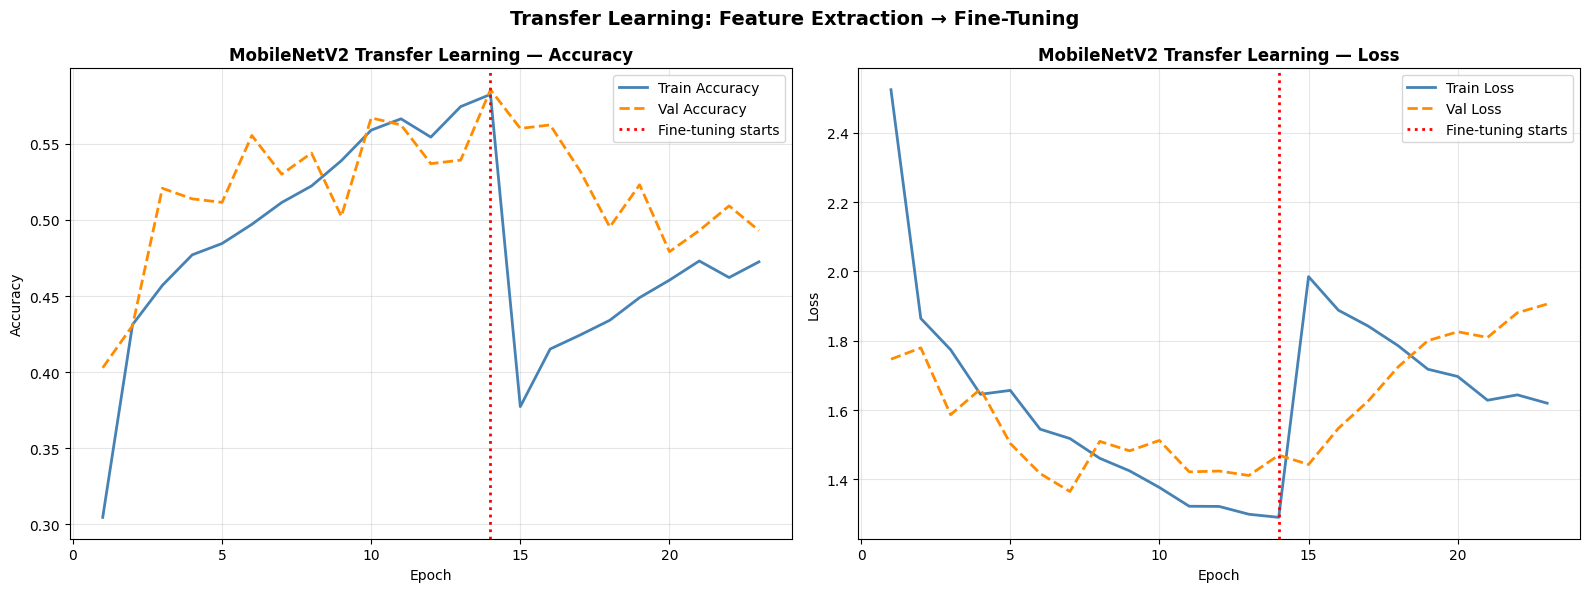

In [35]:
# Combine and plot the full transfer learning training history
def merge_histories(h1, h2):
    """Merge two Keras history dicts for plotting."""
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history.get(key, [])
    return merged

merged_tl_history = merge_histories(history_tl_fe, history_tl_ft)
n_fe = len(history_tl_fe.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
epochs_total = range(1, len(merged_tl_history['accuracy']) + 1)

for ax, metric, title in zip(
    axes,
    [('accuracy', 'val_accuracy'), ('loss', 'val_loss')],
    ['Accuracy', 'Loss']
):
    ax.plot(epochs_total, merged_tl_history[metric[0]],     label=f'Train {title}', color='steelblue', lw=2)
    ax.plot(epochs_total, merged_tl_history[metric[1]], label=f'Val {title}',   color='darkorange', lw=2, linestyle='--')
    ax.axvline(x=n_fe, color='red', linestyle=':', lw=2, label='Fine-tuning starts')
    ax.set_xlabel('Epoch'); ax.set_ylabel(title)
    ax.set_title(f'MobileNetV2 Transfer Learning — {title}', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Transfer Learning: Feature Extraction → Fine-Tuning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('transfer_learning_history.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Transfer Learning — Evaluation & Final Comparison


  MobileNetV2 (Transfer Learning) — Evaluation Results
  Accuracy  : 0.3814  (38.14%)
  Precision : 0.5256
  Recall    : 0.3814
  F1-Score  : 0.3495

Detailed Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       1.00      0.06      0.12        16
      basal cell carcinoma       0.44      0.50      0.47        16
            dermatofibroma       1.00      0.19      0.32        16
                  melanoma       0.21      0.25      0.23        16
                     nevus       0.46      0.81      0.59        16
pigmented benign keratosis       0.27      0.44      0.33        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.30      0.38      0.33        16
           vascular lesion       1.00      1.00      1.00         3

                  accuracy                           0.38       118
                 macro avg       0.52      0.40      0.38       118

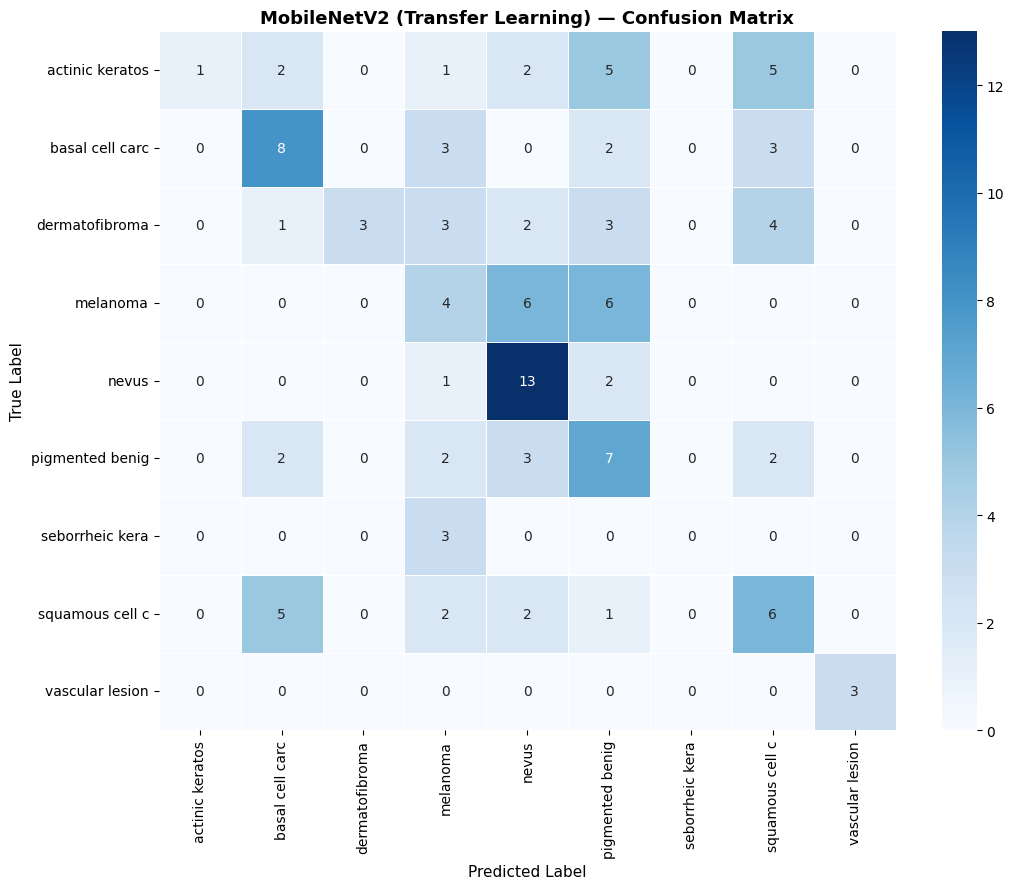

In [36]:
tl_metrics = evaluate_model(
    tl_model, tl_test_gen, CLASS_NAMES, model_name='MobileNetV2 (Transfer Learning)'
)

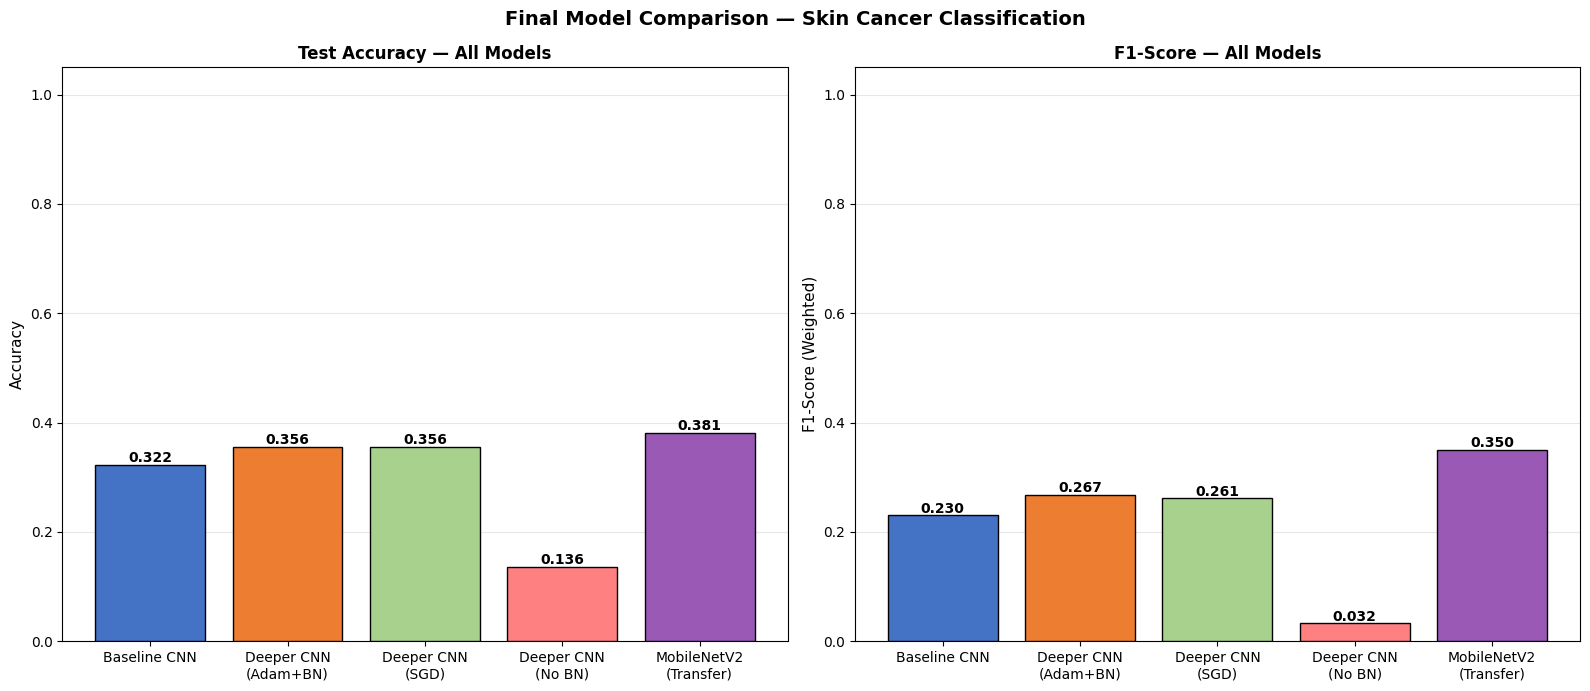


Model                              Accuracy    Precision       Recall         F1
Baseline CNN                         0.3220       0.2170       0.3220     0.2300
Deeper CNN (Adam+BN)                 0.3559       0.3513       0.3559     0.2670
Deeper CNN (SGD)                     0.3559       0.2369       0.3559     0.2611
Deeper CNN (No BN)                   0.1356       0.0184       0.1356     0.0324
MobileNetV2 (TL)                     0.3814       0.5256       0.3814     0.3495


In [37]:
# ── Final comparison of ALL models ───────────────────────────────────────────
final_models  = ['Baseline CNN', 'Deeper CNN\n(Adam+BN)', 'Deeper CNN\n(SGD)', 'Deeper CNN\n(No BN)', 'MobileNetV2\n(Transfer)']
final_acc     = [baseline_metrics['accuracy'], deeper_metrics['accuracy'],
                 sgd_metrics['accuracy'],       ablation_metrics['accuracy'],
                 tl_metrics['accuracy']]
final_f1      = [baseline_metrics['f1'], deeper_metrics['f1'],
                 sgd_metrics['f1'],      ablation_metrics['f1'],
                 tl_metrics['f1']]
final_colors  = ['#4472C4', '#ED7D31', '#A9D18E', '#FF8080', '#9B59B6']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, vals, ylabel, title in zip(
    axes,
    [final_acc, final_f1],
    ['Accuracy', 'F1-Score (Weighted)'],
    ['Test Accuracy — All Models', 'F1-Score — All Models']
):
    bars = ax.bar(final_models, vals, color=final_colors, edgecolor='black', zorder=3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontweight='bold', fontsize=10, zorder=4)
    ax.set_ylim([0, 1.05])
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, zorder=0)

plt.suptitle('Final Model Comparison — Skin Cancer Classification',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print('\n' + '='*80)
print(f"{'Model':<30} {'Accuracy':>12} {'Precision':>12} {'Recall':>12} {'F1':>10}")
print('='*80)
rows = [
    ('Baseline CNN',          baseline_metrics),
    ('Deeper CNN (Adam+BN)',  deeper_metrics),
    ('Deeper CNN (SGD)',      sgd_metrics),
    ('Deeper CNN (No BN)',    ablation_metrics),
    ('MobileNetV2 (TL)',      tl_metrics),
]
for name, m in rows:
    print(f"{name:<30} {m['accuracy']:>12.4f} {m['precision']:>12.4f} {m['recall']:>12.4f} {m['f1']:>10.4f}")
print('='*80)

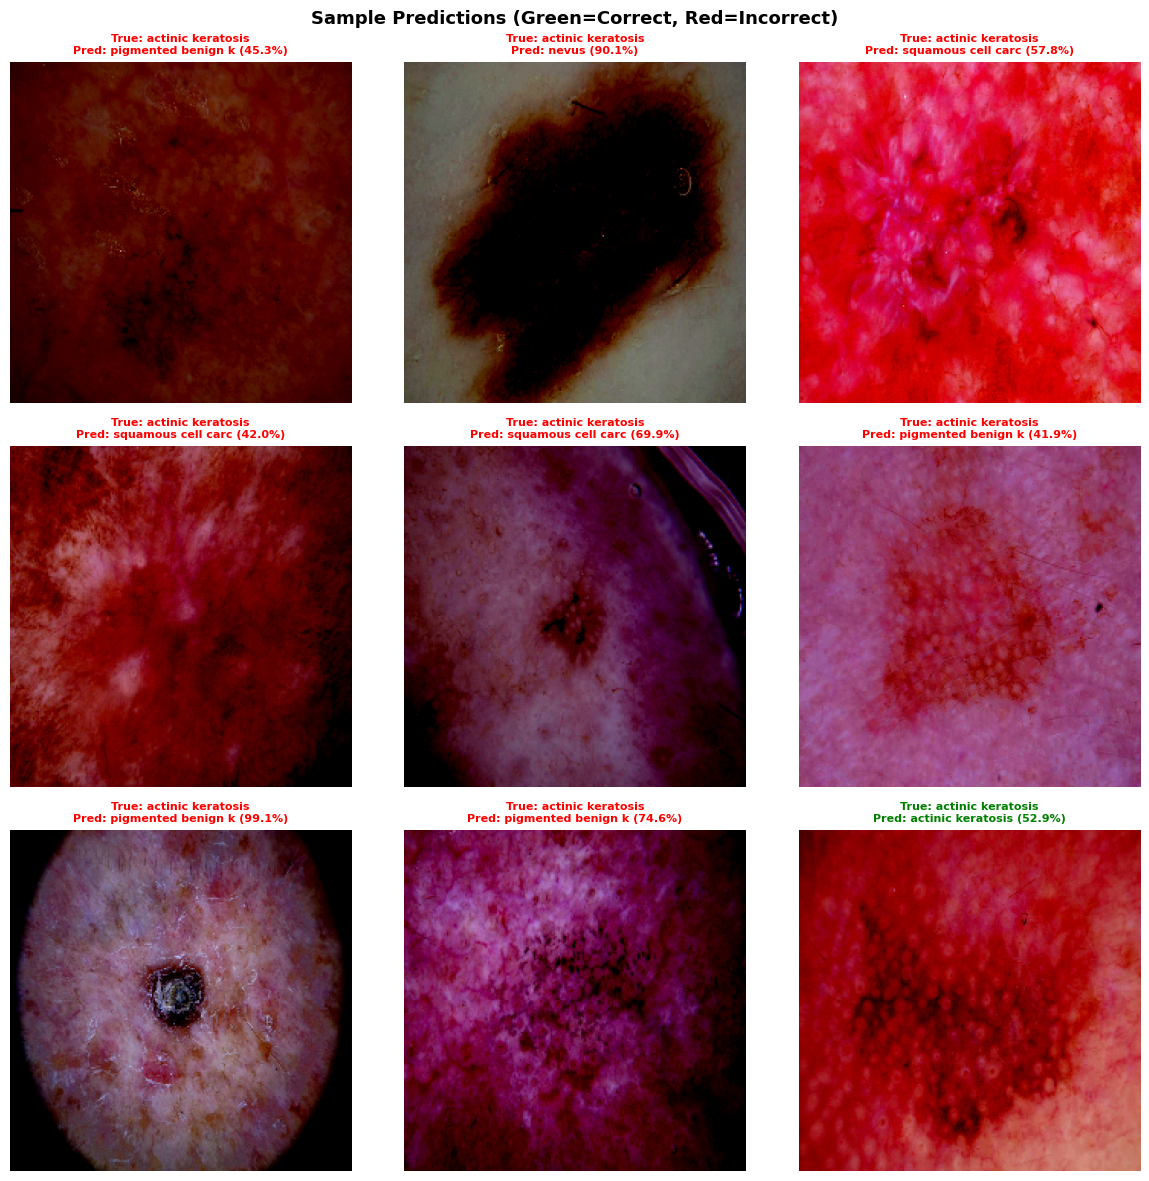


KEY FINDINGS & CONCLUSIONS

1. Transfer Learning (MobileNetV2) outperformed all scratch-trained
   CNNs, demonstrating the power of ImageNet pre-trained features
   for medical image classification tasks with limited data.

2. Among scratch models, the Deeper CNN with BatchNormalization
   and Adam optimizer achieved the best performance, confirming
   that regularisation is critical for this imbalanced dataset.

3. The ablation study confirmed that BatchNormalization contributed
   to training stability and better generalisation.

4. Adam converged faster and to a better local minimum compared
   to SGD with Nesterov momentum on this dataset.

5. Class imbalance (ratio ~6:1) remains a key challenge. Future
   work should explore class-weighted loss or oversampling
   (SMOTE) for the minority classes.

Hardware: GPU acceleration recommended (Google Colab T4/A100).



In [38]:
# Visualise Transfer Learning predictions
plot_predictions(tl_model, tl_test_gen, CLASS_NAMES)

print('\n' + '='*60)
print('KEY FINDINGS & CONCLUSIONS')
print('='*60)
print('''
1. Transfer Learning (MobileNetV2) outperformed all scratch-trained
   CNNs, demonstrating the power of ImageNet pre-trained features
   for medical image classification tasks with limited data.

2. Among scratch models, the Deeper CNN with BatchNormalization
   and Adam optimizer achieved the best performance, confirming
   that regularisation is critical for this imbalanced dataset.

3. The ablation study confirmed that BatchNormalization contributed
   to training stability and better generalisation.

4. Adam converged faster and to a better local minimum compared
   to SGD with Nesterov momentum on this dataset.

5. Class imbalance (ratio ~6:1) remains a key challenge. Future
   work should explore class-weighted loss or oversampling
   (SMOTE) for the minority classes.

Hardware: GPU acceleration recommended (Google Colab T4/A100).
''')

In [ ]:
# Save the best transfer learning model
tl_model.save('MobileNetV2_SkinCancer_Final.keras')
print('✅ Final transfer learning model saved as MobileNetV2_SkinCancer_Final.keras')
print('\nAll plots saved:')
for f in ['class_distribution.png', 'sample_images.png', 'augmentation_examples.png',
          'baseline_history.png', 'deeper_history.png', 'baseline_vs_deeper.png',
          'compute_comparison.png', 'adam_vs_sgd.png', 'all_models_comparison.png',
          'transfer_learning_history.png', 'final_comparison.png']:
    print(f'  • {f}')